# Tugas 1 - Klasifikasi Jamur dengan Naive Bayes

| Nama | NRP |
|------|-----|
| Mahardika Indra Pratama Ilyasa | 5054251045|

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Mushroom Dataset dari UCI Machine Learning Repository.

Dataset dapat diakses melalui:
- https://www.kaggle.com/datasets/uciml/mushroom-classification

Untuk metadata / penjelasan mengenai dataset bisa mengakses link berikut:
- https://archive.ics.uci.edu/dataset/73/mushroom

Tujuan utama dari tugas ini adalah membangun dan membandingkan tiga varian Naive Bayes, yaitu Categorical NB, Bernoulli NB, dan Multinomial NB, untuk mengklasifikasikan apakah suatu jamur dapat dimakan (edible) atau beracun (poisonous).

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan untuk masing-masing varian Naive Bayes.
3. Eksperimen Model
   - Bangun model Categorical NB, Bernoulli NB, dan Multinomial NB.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil ketiga model dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [102]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.feature_selection import mutual_info_classif
from sklearn.naive_bayes import CategoricalNB, BernoulliNB, MultinomialNB
from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score,
                             precision_score, recall_score, auc,
                             roc_curve, roc_auc_score)


In [ ]:
# Load dataset dan tampilkan beberapa baris pertama.
# Semua nilai pada dataset berupa single character yang merupakan kode singkatan dari kategori.
# Contoh: pada kolom class, e = edible dan p = poisonous.
data = pd.read_csv('sample_data/mushrooms.csv')
display(data.head())
data.info()
data.describe(include='object')


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


In [ ]:
# Tampilkan informasi dasar dataset: jumlah baris dan kolom, tipe data, dan jumlah missing value.
# Perhatikan kolom stalk-root yang memiliki nilai '?' sebagai representasi missing value.
print(f"Bentuk dataset (baris, kolom): {data.shape}")
print("\nTipe data dan info kolom:")
data.info()

print("\nJumlah missing value (pandas):")
print(data.isnull().sum())

print(f"\nJumlah '?' pada kolom stalk-root: {(data['stalk-root'] == '?').sum()}")

Bentuk dataset (baris, kolom): (8124, 23)

Tipe data dan info kolom:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-sur

In [ ]:
# Tampilkan jumlah nilai unik pada setiap fitur.
# Perhatikan variasi jumlah kategori antar fitur, misalnya veil-type hanya punya 1 nilai unik.
print("Jumlah nilai unik per kolom:")
print(data.nunique())

single_val_cols = [col for col in data.columns if data[col].nunique() == 1]
print(f"\nKolom dengan hanya 1 nilai unik: {single_val_cols}")

Jumlah nilai unik per kolom:
class                        2
cap-shape                    6
cap-surface                  4
cap-color                   10
bruises                      2
odor                         9
gill-attachment              2
gill-spacing                 2
gill-size                    2
gill-color                  12
stalk-shape                  2
stalk-root                   5
stalk-surface-above-ring     4
stalk-surface-below-ring     4
stalk-color-above-ring       9
stalk-color-below-ring       9
veil-type                    1
veil-color                   4
ring-number                  3
ring-type                    5
spore-print-color            9
population                   6
habitat                      7
dtype: int64

Kolom dengan hanya 1 nilai unik: ['veil-type']


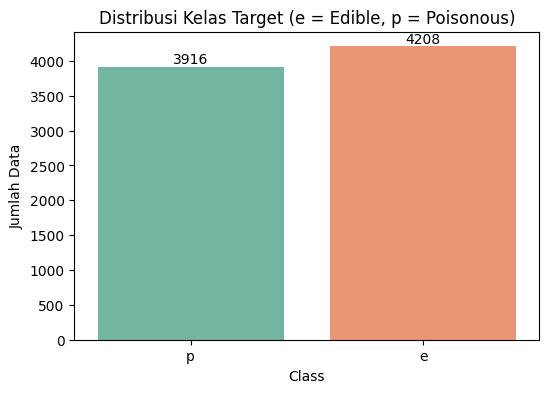

Persentase distribusi target:
class
e    51.797144
p    48.202856
Name: proportion, dtype: float64


In [ ]:
# Tampilkan distribusi kelas target (class) dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=data, x="class", hue="class", palette="Set2", legend=False)
plt.title("Distribusi Kelas Target (e = Edible, p = Poisonous)")
plt.xlabel("Class")
plt.ylabel("Jumlah Data")

ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1]) # Jika ada lebih dari 1 kategori 'hue'

plt.show()

print("Persentase distribusi target:")
print(data["class"].value_counts(normalize=True) * 100)

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

In [ ]:
# Analisis hubungan setiap fitur kategorikal dengan class
# Menggunakan Chi-Square dan Mutual Information

eda_data = data.copy()

eda_data["class_num"] = eda_data["class"].map({"e": 0, "p": 1})

feature_cols = [col for col in eda_data.columns
                if col not in ["class", "class_num"]]

hasil_eda = []

for col in feature_cols:
    contingency_table = pd.crosstab(eda_data[col], eda_data["class_num"])

    chi2, p_value, dof, expected = chi2_contingency(contingency_table)

    X_feature = pd.factorize(eda_data[col])[0].reshape(-1, 1)
    mi = mutual_info_classif(
        X_feature,
        eda_data["class_num"],
        discrete_features=True,
        random_state=42
    )[0]

    hasil_eda.append({
        "Feature": col,
        "Chi-Square": chi2,
        "p-value": p_value,
        "Mutual Information": mi
    })

hasil_eda = pd.DataFrame(hasil_eda)

hasil_eda = hasil_eda.sort_values(
    by="Mutual Information",
    ascending=False
).reset_index(drop=True)

hasil_eda

,Feature,Chi-Square,p-value,Mutual Information
0,odor,7659.726740,0.000000e+00,0.628043
1,spore-print-color,4602.033170,0.000000e+00,0.333199
2,gill-color,3765.714086,0.000000e+00,0.289027
3,ring-type,2956.619278,0.000000e+00,0.220436
4,stalk-surface-above-ring,2808.286287,0.000000e+00,0.197357
5,stalk-surface-below-ring,2684.474076,0.000000e+00,0.188463
6,stalk-color-above-ring,2237.898496,0.000000e+00,0.175952
7,stalk-color-below-ring,2152.390891,0.000000e+00,0.167337
8,gill-size,2366.834257,0.000000e+00,0.159531
9,population,1929.740891,0.000000e+00,0.139987


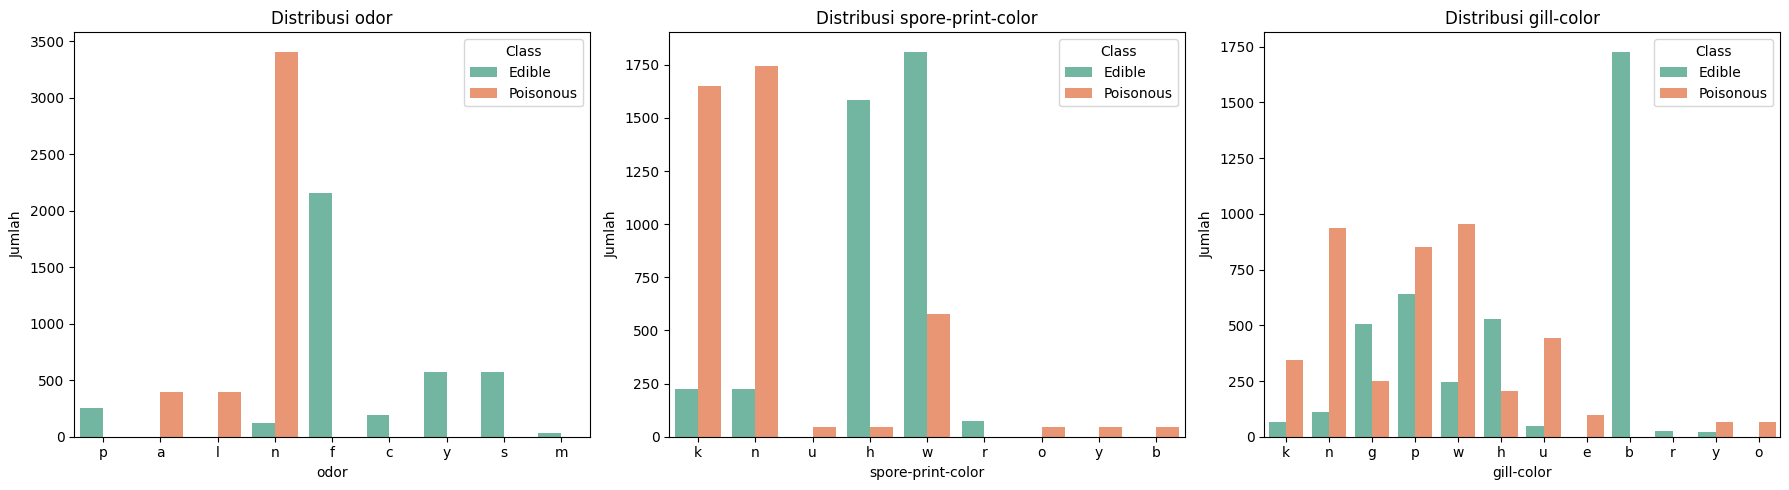

In [ ]:
#Tabel distribusi 3
top = hasil_eda.head(3)["Feature"].tolist()
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(top):
    sns.countplot(
        data=data,
        x=col,
        hue="class",
        ax=axes[i],
        palette="Set2"
    )

    axes[i].set_title(f"Distribusi {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Jumlah")
    axes[i].legend(title="Class", labels=["Edible", "Poisonous"])

plt.tight_layout()
plt.show()

# 2. Preprocessing

Karena semua fitur bertipe kategorikal, setiap varian Naive Bayes membutuhkan representasi data yang berbeda:

| Model | Representasi yang dibutuhkan | Preprocessing |
|---|---|---|
| Categorical NB | Integer per kategori | OrdinalEncoder |
| Bernoulli NB | Binary 0/1 per kategori | LabelBinarizer / OneHotEncoder |
| Multinomial NB | Count / frekuensi non-negatif | OneHotEncoder |

In [ ]:
# Pilih strategi yang sesuai: drop baris, ganti dengan modus, atau jadikan kategori tersendiri.
# '?' dijadikan kategori tersendiri
data["stalk-root"] = data["stalk-root"].replace("?", "m")

print("Distribusi stalk-root setelah penanganan missing value:")
print(data["stalk-root"].value_counts())
# Mengecek jumlah nilai '?'
missing_stalk_root = (data["stalk-root"] == "?").sum()

Distribusi stalk-root setelah penanganan missing value:
stalk-root
b    3776
m    2480
e    1120
c     556
r     192
Name: count, dtype: int64


In [ ]:
# Periksa apakah ada fitur yang hanya memiliki satu nilai unik.
constant_cols = [col for col in data.columns if data[col].nunique() == 1]
print(f"Kolom tanpa variasi: {constant_cols}")

# Drop kolom veil-type karena tidak memberikan informasi
data = data.drop(columns=constant_cols)
print(f"Jumlah kolom tersisa: {data.shape[1]}")

Kolom tanpa variasi: ['veil-type']
Jumlah kolom tersisa: 22


In [ ]:
# Pisahkan fitur (X) dan target (y).
# Encode target: e = 0 (edible), p = 1 (poisonous).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.
X = data.drop(columns=["class"])
y = data["class"].map({"e": 0, "p": 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Ukuran Train: {X_train.shape}, Ukuran Test: {X_test.shape}")
print(f"Proporsi target pada Train: {y_train.mean():.4f}")
print(f"Proporsi target pada Test: {y_test.mean():.4f}")

Ukuran Train: (6499, 21), Ukuran Test: (1625, 21)
Proporsi target pada Train: 0.4821
Proporsi target pada Test: 0.4818


In [ ]:
# Preprocessing untuk Categorical NB:
# Gunakan OrdinalEncoder untuk mengubah setiap kategori menjadi integer.
# Contoh: cap-shape b=0, c=1, f=2, k=3, s=4, x=5
# Fit hanya pada train set, transform pada train set dan test set.

oe = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
X_train_cat = oe.fit_transform(X_train)
X_test_cat = oe.transform(X_test)

print(f"Bentuk matriks Categorical (Train): {X_train_cat.shape}")

Bentuk matriks Categorical (Train): (6499, 21)


In [ ]:
# Preprocessing untuk Bernoulli NB dan Multinomial NB:
# Gunakan OneHotEncoder untuk mengubah setiap kategori menjadi representasi binary.
# Hasilnya berupa matriks sparse dengan nilai 0 dan 1.
# Fit hanya pada train set, transform pada train set dan test set.

ohe = OneHotEncoder(handle_unknown="ignore")
X_train_ohe = ohe.fit_transform(X_train)
X_test_ohe = ohe.transform(X_test)

print("Shape X_train:", X_train_ohe.shape)
print("Shape X_test :", X_test_ohe.shape)
print("Tipe data   :", type(X_train_ohe))

Shape X_train: (6499, 116)
Shape X_test : (1625, 116)
Tipe data   : <class 'scipy.sparse._csr.csr_matrix'>


# 3. Eksperimen Model

## 3.1 Categorical Naive Bayes

CategoricalNB adalah varian yang paling sesuai untuk dataset ini karena semua fitur memang bertipe kategorikal. Model menghitung P(fitur=kategori | kelas) secara langsung untuk setiap kategori pada setiap fitur.

In [ ]:
# Inisialisasi dan latih model CategoricalNB menggunakan train set hasil OrdinalEncoder.
cat_nb = CategoricalNB()
cat_nb.fit(X_train_cat, y_train)

CategoricalNB()

In [ ]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_cat = cat_nb.predict(X_test_cat)
y_prob_cat = cat_nb.predict_proba(X_test_cat)[:, 1]

## 3.2 Bernoulli Naive Bayes

BernoulliNB bekerja pada representasi binary. Dengan OneHotEncoder, setiap kategori menjadi kolom tersendiri bernilai 0 atau 1, sehingga model memperlakukan setiap kategori sebagai fitur binary ada/tidak ada.

In [ ]:
# Inisialisasi dan latih model BernoulliNB menggunakan train set hasil OneHotEncoder.
bern_nb = BernoulliNB()
bern_nb.fit(X_train_ohe, y_train)

BernoulliNB()

In [ ]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_bern = bern_nb.predict(X_test_ohe)
y_prob_bern = bern_nb.predict_proba(X_test_ohe)[:, 1]

## 3.3 Multinomial Naive Bayes

MultinomialNB membutuhkan input non-negatif dan menginterpretasikannya sebagai frekuensi. Dengan OneHotEncoder yang menghasilkan nilai 0 dan 1, model dapat menerimanya sebagai counts meskipun secara semantik tiap nilai hanya menandakan ada/tidak ada kategori.

In [ ]:
# Inisialisasi dan latih model MultinomialNB menggunakan train set hasil OneHotEncoder.
multi_nb = MultinomialNB()
multi_nb.fit(X_train_ohe, y_train)

MultinomialNB()

In [ ]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_multi = multi_nb.predict(X_test_ohe)
y_prob_multi = multi_nb.predict_proba(X_test_ohe)[:, 1]

# 4. Evaluasi Model

In [ ]:
# Tampilkan metrik evaluasi untuk setiap model: Accuracy, Precision, Recall, dan F1-Score.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.

models = {
    "Categorical NB": (y_pred_cat, y_prob_cat),
    "Bernoulli NB": (y_pred_bern, y_prob_bern),
    "Multinomial NB": (y_pred_multi, y_prob_multi),
}

metrics_list = []
for name, (pred, prob) in models.items():
  metrics_list.append({
      "Model": name,
      "Accuracy": accuracy_score(y_test, pred),
      "Precision": precision_score(y_test, pred),
      "Recall": recall_score(y_test, pred),
      "F1-Score": f1_score(y_test, pred),
      "ROC AUC": roc_auc_score(y_test, prob),
  })

df_metrics = pd.DataFrame(metrics_list)
display(df_metrics.style.format(precision=4))

,Model,Accuracy,Precision,Recall,F1-Score,ROC AUC
0,Categorical NB,0.9458,0.9901,0.8966,0.9410,0.9972
1,Bernoulli NB,0.9329,0.9814,0.8774,0.9265,0.9954
2,Multinomial NB,0.9458,0.9901,0.8966,0.9410,0.9972


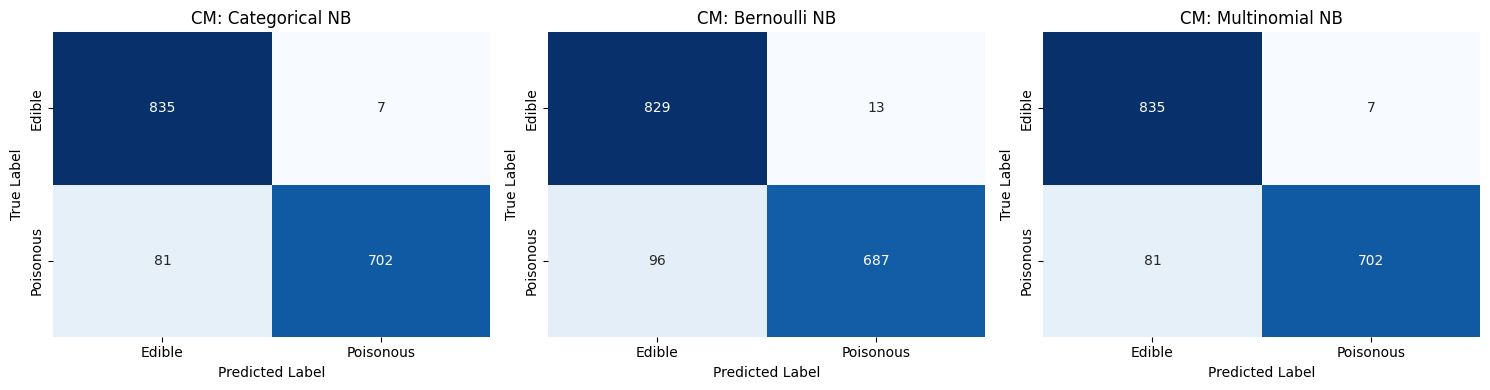

In [ ]:
# Tampilkan Confusion Matrix setiap model dalam bentuk heatmap.
# Susun ketiganya dalam satu baris subplot.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
preds = [
    ("Categorical NB", y_pred_cat),
    ("Bernoulli NB", y_pred_bern),
    ("Multinomial NB", y_pred_multi),
]

for idx, (name, pred) in enumerate(preds):
  cm = confusion_matrix(y_test, pred)
  sns.heatmap(
      cm,
      annot=True,
      fmt="d",
      cmap="Blues",
      cbar=False,
      ax=axes[idx],
      xticklabels=["Edible", "Poisonous"],
      yticklabels=["Edible", "Poisonous"],
  )
  axes[idx].set_title(f"CM: {name}")
  axes[idx].set_xlabel("Predicted Label")
  axes[idx].set_ylabel("True Label")

plt.tight_layout()
plt.show()

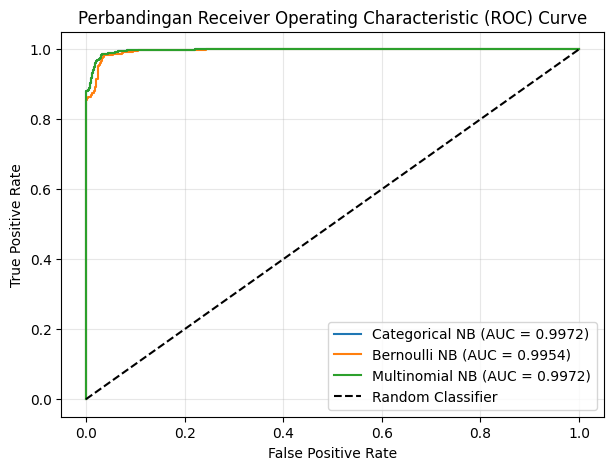

In [ ]:
# Tampilkan ROC Curve ketiga model dalam satu plot beserta nilai AUC masing-masing.

plt.figure(figsize=(7, 5))
probs = [
    ("Categorical NB", y_prob_cat),
    ("Bernoulli NB", y_prob_bern),
    ("Multinomial NB", y_prob_multi),
]

for name, prob in probs:
  fpr, tpr, _ = roc_curve(y_test, prob)
  roc_auc = auc(fpr, tpr)
  plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.4f})")

plt.plot([0, 1], [0, 1], "k--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Perbandingan Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

# 5. Analisis

#### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan. Bandingkan performa Categorical NB, Bernoulli NB, dan Multinomial NB berdasarkan hasil evaluasi. Kaitkan perbedaan performa dengan perbedaan representasi data yang digunakan oleh masing-masing model. Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan.

#Laporan Praktikum
##Bab:
###1. EDA
###2. Preprocessing
###3. Eksperimen Model Naive Bayes
###4. Evaluasi Model
###5. Analisis dan Kesimpulan  
---

# BAB 1. Persiapan Dataset dan Exploratory Data Analysis

## 1.1 Deskripsi dan Penjelajahan Data

Dataset yang digunakan adalah **Mushroom Dataset** yang berisi karakteristik jamur untuk mengklasifikasikan jamur menjadi dua kelas, yaitu **edible (e)** dan **poisonous (p)**.

| Keterangan   |                         Nilai |
| ------------ | ----------------------------: |
| Jumlah data  |                         8.124 |
| Jumlah kolom |                            23 |
| Tipe data    |                   Kategorikal |
| Target       |                       `class` |
| Kelas target | Edible (`e`), Poisonous (`p`) |

Penjelajahan awal dilakukan untuk mengetahui struktur data, tipe data, nilai unik, serta kondisi dataset. Hasil pemeriksaan menunjukkan tidak terdapat nilai `NaN`. Namun, ditemukan nilai `?` pada atribut `stalk-root` sebanyak 2.480 data. Selain itu, atribut `veil-type` hanya memiliki satu nilai sehingga tidak memberikan variasi informasi.

## 1.2 Analisis Nilai Unik dan Distribusi Kelas

Analisis nilai unik dilakukan untuk mengetahui variasi kategori pada setiap fitur. Nilai `?` pada `stalk-root` dipertahankan sebagai kategori khusus dan akan ditangani pada tahap preprocessing. Atribut `veil-type` memiliki satu kategori sehingga nantinya dapat dihapus karena tidak memberikan informasi pembeda.

Dataset memiliki dua kelas target, yaitu `e` (*edible*) dan `p` (*poisonous*). Distribusi kedua kelas divisualisasikan untuk melihat perbandingan jumlah data pada masing-masing kelas.

## 1.3 EDA Tambahan

EDA tambahan dilakukan untuk mengetahui fitur yang memiliki hubungan atau memberikan informasi paling besar terhadap kelas jamur. Analisis menggunakan **Chi-Square** dan **Mutual Information (MI)**.

### Chi-Square

Uji Chi-Square digunakan untuk mengetahui hubungan antara fitur kategorikal dengan kelas target.

$$
\chi^2 = \sum \frac{(O-E)^2}{E}
$$

Keterangan:

* $O$ = frekuensi observasi
* $E$ = frekuensi ekspektasi

Nilai *p-value* kurang dari 0,05 menunjukkan adanya hubungan yang signifikan secara statistik.

### Mutual Information

Mutual Information digunakan untuk mengukur informasi yang diberikan suatu fitur terhadap target.

$$
I(X;Y)=\sum_{x,y}p(x,y)\log\left(\frac{p(x,y)}{p(x)p(y)}\right)
$$

Semakin besar nilai MI, semakin besar informasi yang diberikan fitur terhadap target pada analisis ini.

### Hasil EDA Tambahan

Berikut beberapa fitur dengan nilai Mutual Information tertinggi:

| Peringkat | Feature                    | Chi-Square | p-value | Mutual Information |
| --------: | -------------------------- | ---------: | ------: | -----------------: |
|         1 | `odor`                     |    7659,73 | < 0,001 |             0,6280 |
|         2 | `spore-print-color`        |    4602,03 | < 0,001 |             0,3332 |
|         3 | `gill-color`               |    3765,71 | < 0,001 |             0,2890 |
|         4 | `ring-type`                |    2956,62 | < 0,001 |             0,2204 |
|         5 | `stalk-surface-above-ring` |    2808,29 | < 0,001 |             0,1974 |

Berdasarkan hasil tersebut, `odor`, `spore-print-color`, dan `gill-color` memiliki nilai Mutual Information tertinggi. Hal ini menunjukkan bahwa ketiga fitur tersebut memberikan informasi yang relatif besar dalam membedakan kelas edible dan poisonous pada dataset. Sementara itu, `veil-type` memiliki nilai MI sebesar 0 karena hanya memiliki satu kategori.

---

# BAB 2. Preprocessing

Preprocessing dilakukan untuk menyiapkan data kategorikal agar dapat digunakan oleh masing-masing varian Naive Bayes.

## 2.1 Penanganan Data dan Pembagian Dataset

Nilai `?` pada atribut `stalk-root` diperlakukan sebagai kategori tersendiri dengan mengubahnya menjadi `m`. Selanjutnya, atribut yang hanya memiliki satu nilai unik dihapus karena tidak memberikan variasi informasi. Pada dataset ini, atribut `veil-type` termasuk ke dalam atribut tersebut.

Setelah itu, fitur dan target dipisahkan. Target `class` diubah menjadi nilai numerik, yaitu `e = 0` untuk *edible* dan `p = 1` untuk *poisonous*.

Dataset kemudian dibagi menjadi data latih dan data uji dengan perbandingan 80:20 menggunakan `train_test_split` dan `stratify=y`.

| Data     | Jumlah Baris | Jumlah Fitur |
| -------- | -----------: | -----------: |
| Training |        6.499 |           21 |
| Testing  |        1.625 |           21 |

Penggunaan `stratify=y` menjaga proporsi kelas pada data training dan testing tetap relatif sama. Proporsi kelas `p` pada data training sebesar 0,4821 dan pada data testing sebesar 0,4818.

## 2.2 Encoding untuk Categorical Naive Bayes

Categorical Naive Bayes menggunakan `OrdinalEncoder` untuk mengubah setiap kategori menjadi kode integer.

```text
Kategori → kode integer
```

Contohnya, kategori pada suatu fitur dapat direpresentasikan menjadi `0, 1, 2, ...`. Encoding ini hanya mengubah bentuk data menjadi numerik; kode tersebut tidak menunjukkan adanya hubungan urutan antar kategori.

Pada kode digunakan:

```python
OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)
```

Encoder hanya di-*fit* menggunakan data training, kemudian digunakan untuk melakukan transformasi pada data training dan testing.

## 2.3 Encoding untuk Bernoulli dan Multinomial Naive Bayes

Bernoulli Naive Bayes dan Multinomial Naive Bayes menggunakan `OneHotEncoder`.

Setiap kategori diubah menjadi fitur binary dengan nilai `0` dan `1`. Hasil encoding berbentuk matriks *sparse*.

| Data         |    Bentuk Matriks |
| ------------ | ----------------: |
| Training     |       6.499 × 116 |
| Testing      |       1.625 × 116 |
| Tipe matriks | CSR Sparse Matrix |

Dengan demikian, satu kategori direpresentasikan sebagai satu kolom khusus yang menunjukkan apakah kategori tersebut muncul pada suatu data.

---

# BAB 3. Eksperimen Model Naive Bayes

Eksperimen dilakukan menggunakan tiga varian Naive Bayes, yaitu CategoricalNB, BernoulliNB, dan MultinomialNB. Ketiga model menggunakan data training yang sama, tetapi representasi fiturnya berbeda.

Secara umum, Naive Bayes menggunakan Teorema Bayes:

$$
P(C|X)=\frac{P(X|C)P(C)}{P(X)}
$$

dengan:

* $P(C|X)$ = probabilitas kelas $C$ berdasarkan fitur $X$
* $P(X|C)$ = probabilitas fitur berdasarkan kelas
* $P(C)$ = probabilitas awal kelas
* $P(X)$ = probabilitas fitur

## 3.1 Categorical Naive Bayes

CategoricalNB dilatih menggunakan data hasil `OrdinalEncoder`.

```python
cat_nb = CategoricalNB()
cat_nb.fit(X_train_cat, y_train)
```

Model kemudian digunakan untuk menghasilkan prediksi kelas dan probabilitas kelas *poisonous* pada data testing.

CategoricalNB bekerja dengan menghitung probabilitas setiap kategori fitur terhadap masing-masing kelas. Representasi ini sesuai dengan karakteristik asli dataset yang seluruh fiturnya bersifat kategorikal.

## 3.2 Bernoulli Naive Bayes

BernoulliNB dilatih menggunakan data hasil `OneHotEncoder`.

```python
bern_nb = BernoulliNB()
bern_nb.fit(X_train_ohe, y_train)
```

Pada representasi ini, setiap kategori menjadi fitur binary dengan nilai 0 atau 1. Model kemudian mempelajari hubungan keberadaan atau ketidakberadaan kategori tersebut terhadap kelas.

## 3.3 Multinomial Naive Bayes

MultinomialNB juga menggunakan data hasil `OneHotEncoder`.

```python
multi_nb = MultinomialNB()
multi_nb.fit(X_train_ohe, y_train)
```

MultinomialNB membutuhkan nilai input non-negatif. Matriks hasil OneHotEncoder memiliki nilai 0 dan 1 sehingga dapat digunakan oleh model. Dalam eksperimen ini, nilai tersebut merepresentasikan keberadaan kategori, bukan frekuensi kata seperti pada penggunaan MultinomialNB yang umum pada data teks.

---

# BAB 4. Evaluasi Model

Evaluasi dilakukan pada data testing menggunakan **Accuracy, Precision, Recall, F1-Score, dan ROC-AUC**. Selain itu, digunakan **Confusion Matrix** dan **ROC Curve** untuk melihat karakteristik hasil klasifikasi secara lebih rinci.

## 4.1 Metrik Evaluasi

### Accuracy

Accuracy menunjukkan proporsi seluruh prediksi yang benar.

$$
Accuracy=\frac{TP+TN}{TP+TN+FP+FN}
$$

### Precision

Precision menunjukkan proporsi prediksi *poisonous* yang benar-benar poisonous.

$$
Precision=\frac{TP}{TP+FP}
$$

### Recall

Recall menunjukkan kemampuan model dalam menemukan data yang sebenarnya *poisonous*.

$$
Recall=\frac{TP}{TP+FN}
$$

### F1-Score

F1-Score merupakan rata-rata harmonik antara Precision dan Recall.

$$
F1=2\times\frac{Precision\times Recall}{Precision+Recall}
$$

### ROC-AUC

ROC-AUC digunakan untuk mengukur kemampuan model dalam membedakan kelas berdasarkan probabilitas prediksi. Nilai AUC semakin mendekati 1 menunjukkan kemampuan diskriminasi yang semakin tinggi.

## 4.2 Hasil Evaluasi

Berdasarkan hasil eksperimen pada data testing, diperoleh:

| Model          | Accuracy | Precision | Recall | F1-Score | ROC-AUC |
| -------------- | -------: | --------: | -----: | -------: | ------: |
| Categorical NB |   94,58% |    99,01% | 89,66% |   94,10% |  99,72% |
| Bernoulli NB   |   93,29% |    98,14% | 87,74% |   92,65% |  99,54% |
| Multinomial NB |   94,58% |    99,01% | 89,66% |   94,10% |  99,72% |

CategoricalNB dan MultinomialNB menghasilkan nilai yang sama pada seluruh metrik yang digunakan. BernoulliNB menghasilkan nilai yang sedikit lebih rendah pada Accuracy, Precision, Recall, F1-Score, dan ROC-AUC.

Perbedaan tersebut berkaitan dengan representasi data yang digunakan. CategoricalNB menggunakan informasi kategori secara langsung melalui encoding kategorikal, sedangkan BernoulliNB dan MultinomialNB menggunakan representasi One-Hot. Pada eksperimen ini, representasi One-Hot menghasilkan performa yang sama untuk MultinomialNB dengan CategoricalNB, sedangkan BernoulliNB menghasilkan performa sedikit lebih rendah.

## 4.3 Confusion Matrix dan ROC Curve

Confusion Matrix digunakan untuk melihat jumlah prediksi yang benar dan salah pada masing-masing kelas.

Komponen confusion matrix terdiri dari:

| Komponen | Keterangan                     |
| -------- | ------------------------------ |
| TP       | Poisonous diprediksi Poisonous |
| TN       | Edible diprediksi Edible       |
| FP       | Edible diprediksi Poisonous    |
| FN       | Poisonous diprediksi Edible    |

Karena kelas `p` dikodekan sebagai `1`, nilai Recall pada tabel menunjukkan kemampuan model dalam mendeteksi jamur *poisonous*. Nilai Recall CategoricalNB dan MultinomialNB sebesar **89,66%** berarti sebagian data *poisonous* pada data testing masih diprediksi sebagai *edible*. BernoulliNB memiliki Recall **87,74%**, sehingga pada eksperimen ini terdapat proporsi kesalahan deteksi kelas *poisonous* yang lebih besar dibandingkan dua model lainnya.

Pada ROC Curve, ketiga model memiliki nilai AUC di atas **0,99**. Hal ini menunjukkan bahwa ketiga model memiliki kemampuan diskriminasi yang sangat tinggi pada data testing. CategoricalNB dan MultinomialNB memperoleh AUC **0,9972**, sedangkan BernoulliNB memperoleh **0,9954**.

Secara keseluruhan, hasil evaluasi menunjukkan bahwa ketiga varian Naive Bayes mampu melakukan klasifikasi dengan performa tinggi pada dataset Mushroom. CategoricalNB dan MultinomialNB menghasilkan metrik evaluasi yang identik dalam eksperimen ini, sedangkan BernoulliNB memiliki nilai yang sedikit lebih rendah. Hasil tersebut menjadi dasar untuk pembahasan lebih lanjut pada bab analisis.

### 4.4 Kesimpulan Model
* **Performa Categorical NB dan Multinomial NB:** Keduanya memperoleh hasil evaluasi yang identik dan tertinggi, yaitu *accuracy* 94,58%, *precision* 99,01%, *recall* 89,66%, *F1-score* 94,10%, dan ROC-AUC 99,72%.
* **Performa Bernoulli NB:** Menghasilkan metrik yang sedikit lebih rendah dari dua model lainnya, yaitu *accuracy* 93,29%, *precision* 98,14%, *recall* 87,74%, *F1-score* 92,65%, dan ROC-AUC 99,54%.
* **Pengaruh Representasi Data:** Perbedaan hasil berkaitan dengan bentuk input data. Categorical NB menggunakan representasi *encoding* kategori, sedangkan Bernoulli NB dan Multinomial NB menggunakan representasi biner (nilai 0/1) hasil *One-Hot Encoding*.
* **Kesimpulan:** Tidak terdapat satu model tunggal yang dapat dinyatakan lebih unggul antara Categorical NB dan Multinomial NB pada eksperimen ini karena keduanya menghasilkan nilai metrik yang sama persis.


# 6. Kesimpulan dan Saran

#### Berikan kesimpulan dari eksperimen yang telah dilakukan. Saran dapat berupa rekomendasi untuk eksperimen selanjutnya, perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

# 5. Kesimpulan dan Saran

## 5.1 Kesimpulan
* **Preprocessing & EDA:** Data disiapkan melalui penanganan nilai `?`, penghapusan fitur konstan (`veil-type`), dan *encoding* dengan pembagian rasio data 80:20. Analisis menunjukkan `odor`, `spore-print-color`, dan `gill-color` adalah fitur paling informatif penentu kelas jamur.
* **Performa Model:** Categorical NB dan Multinomial NB menghasilkan performa tertinggi dan identik (*Accuracy* 94,58%, ROC-AUC 99,72%), sedikit mengungguli Bernoulli NB (*Accuracy* 93,29%). Secara umum, ketiga model berkinerja sangat memuaskan (AUC > 0,99).
* **Catatan Evaluasi:** Meski akurasi dan *precision* sangat tinggi, nilai *recall* yang lebih rendah menandakan masih ada jamur beracun yang berisiko salah diprediksi sebagai *edible*.

## 5.2 Saran
* **Eksplorasi & Evaluasi:** Gunakan *cross-validation* agar evaluasi lebih *robust*, serta uji coba metode *encoding* alternatif untuk melihat dampaknya pada model.
* **Perbandingan Algoritma:** Bandingkan performa Naive Bayes dengan algoritma lain seperti *Decision Tree*, *Random Forest*, atau *Logistic Regression*.
* **Fokus Analisis Kesalahan:** Lakukan analisis mendalam pada kasus kesalahan prediksi jamur beracun yang ditebak aman (*False Negative*), mengingat konsekuensinya yang sangat fatal.